# 01 - Quantum Feature Maps and Kernels

This notebook introduces the first essential idea in quantum machine learning (QML): use a quantum circuit as a feature map.

A classical model often starts by transforming data,

$$
x \in \mathbb{R}^d
\quad \longmapsto \quad
\phi(x) \in \mathbb{R}^D.
$$

A quantum feature map transforms data into a quantum state,

$$
x \in \mathbb{R}^d
\quad \longmapsto \quad
|\phi(x)\rangle = U_\phi(x)|0\cdots 0\rangle.
$$

Once data are represented as states, a natural similarity measure is the quantum kernel

$$
K(x,z) = |\langle \phi(x) | \phi(z) \rangle|^2.
$$

The examples below use PennyLane for circuits and NumPy/Matplotlib for the surrounding math. The learning algorithms are written directly in the cells: no high-level classifier wrappers are used.


## Why feature maps matter

A feature map changes the geometry of a dataset. A linear classifier in the feature space can become nonlinear in the original input space.

A simple classical example is the map

$$
\phi(x_1,x_2) = [x_1, x_2, x_1^2 + x_2^2]^T.
$$

In the original plane, points inside and outside a circle are not linearly separable. In the lifted feature space, the coordinate \(x_1^2+x_2^2\) exposes the radius and makes separation easier.


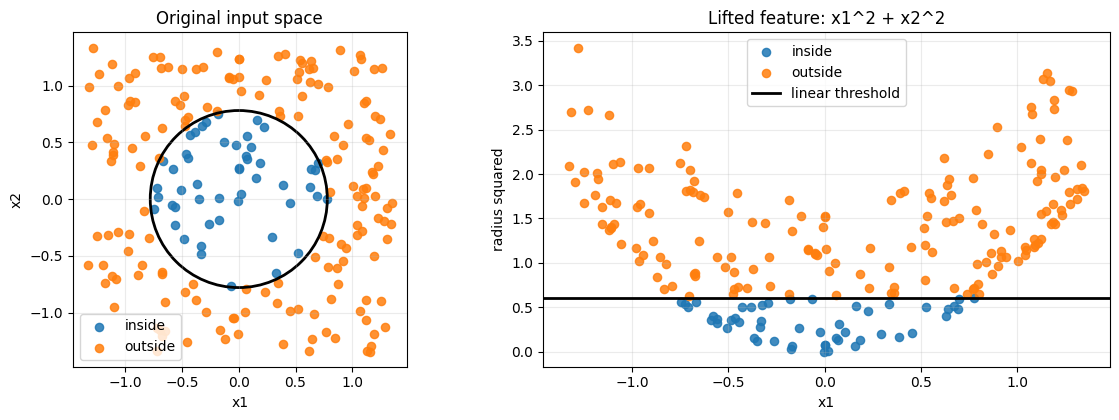

In [ ]:
# Pseudo-code:
#   1. generate radial labels in input space
#   2. lift points with a radius-squared feature
#   3. compare original and lifted geometry

# Classical feature-map intuition: circles become separable after a nonlinear lift.
# Meaning that in the original 2D input space, points that are inside a certain radius (0.78)
# are labeled -1 and points outside that radius are labeled +1. 
# This creates a circular decision boundary that cannot be separated by a linear classifier. 
# However, by lifting the data into a higher-dimensional feature space using the radius-squared feature (x1^2 + x2^2),
# we can transform the circular decision boundary into a linear one, making the classes linearly separable in the lifted feature space.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(4)
n = 220
X = rng.uniform(-1.35, 1.35, size=(n, 2))
radius = np.sqrt(np.sum(X**2, axis=1))
y = np.where(radius > 0.78, 1, -1)

lifted_radius = np.sum(X**2, axis=1)
threshold = 0.78**2

fig = plt.figure(figsize=(12, 4.3))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(X[y == -1, 0], X[y == -1, 1], s=35, color="tab:blue", label="inside", alpha=0.85)
ax1.scatter(X[y == 1, 0], X[y == 1, 1], s=35, color="tab:orange", label="outside", alpha=0.85)
circle = plt.Circle((0, 0), 0.78, fill=False, color="black", linewidth=2)
ax1.add_patch(circle)
ax1.set_title("Original input space")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_aspect("equal", adjustable="box")
ax1.grid(alpha=0.25)
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[y == -1, 0], lifted_radius[y == -1], s=35, color="tab:blue", label="inside", alpha=0.85)
ax2.scatter(X[y == 1, 0], lifted_radius[y == 1], s=35, color="tab:orange", label="outside", alpha=0.85)
ax2.axhline(threshold, color="black", linewidth=2, label="linear threshold")
ax2.set_title("Lifted feature: x1^2 + x2^2")
ax2.set_xlabel("x1")
ax2.set_ylabel("radius squared")
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()


## Quantum Encodings

A **quantum encoding** is a concrete choice of data-dependent circuit

$$
U_\phi(x),
$$

which maps a classical input \(x\) into a quantum state:

$$
x
\quad \longmapsto \quad
|\phi(x)\rangle = U_\phi(x)|0\cdots 0\rangle.
$$

The goal is to represent classical data in a Hilbert space, where similarities, distances, and decision boundaries can be computed through quantum states, measurements, or kernels.

Common encoding strategies include:

| Encoding | Idea | Typical form |
|---|---|---|
| Basis encoding | Store discrete data directly as computational basis states | \(x = 5 \mapsto |101\rangle\) |
| Amplitude encoding | Store a normalized vector in quantum amplitudes | \(x \mapsto \sum_j x_j |j\rangle\), with \(\|x\|=1\) |
| Angle encoding | Store features as rotation angles | \(x_j \mapsto R_Y(x_j)\), \(R_Z(x_j)\), or \(R_X(x_j)\) |
| Data re-uploading | Encode the same data multiple times across circuit layers | \(U_\theta^{(L)}U_\phi(x)\cdots U_\theta^{(1)}U_\phi(x)|0\rangle\) |

### Basis Encoding

Basis encoding maps classical bit strings to computational basis states. For example,

$$
x = 5 = 101_2
\quad \longmapsto \quad
|101\rangle.
$$

This is natural for discrete or binary data, but it does not directly represent continuous features unless they are first discretized.

### Amplitude Encoding

Amplitude encoding stores a normalized classical vector in the amplitudes of a quantum state:

$$
x =
\begin{bmatrix}
x_0 \\
x_1 \\
\vdots \\
x_{N-1}
\end{bmatrix},
\qquad
\|x\|_2 = 1,
$$

as

$$
|\phi(x)\rangle
=
\sum_{j=0}^{N-1} x_j |j\rangle.
$$

With \(n\) qubits, the state has \(2^n\) amplitudes, so amplitude encoding can represent a \(2^n\)-dimensional vector using \(n\) qubits. The challenge is that preparing an arbitrary amplitude-encoded state can be expensive.

### Angle Encoding

Angle encoding stores features as rotation angles. For example, with one feature and one qubit,

$$
|\phi(x)\rangle = R_Y(x)|0\rangle.
$$

Since

$$
R_Y(x)
=
\begin{bmatrix}
\cos(x/2) & -\sin(x/2) \\
\sin(x/2) & \cos(x/2)
\end{bmatrix},
$$

we get

$$
R_Y(x)|0\rangle
=
\cos(x/2)|0\rangle
+
\sin(x/2)|1\rangle.
$$

So the feature \(x\) changes the quantum state's amplitudes:

$$
P(0) = \cos^2(x/2),
\qquad
P(1) = \sin^2(x/2).
$$

For multiple features, we can encode one feature per qubit:

$$
|\phi(x)\rangle
=
R_Y(x_1) \otimes R_Y(x_2) \otimes \cdots \otimes R_Y(x_d)
|0\cdots 0\rangle.
$$

Equivalently, in circuit notation:

$$
U_\phi(x)
=
\prod_{j=1}^d R_Y(x_j).
$$

Angle encoding is easy to implement and common in small QML examples. It is especially useful when the number of features is comparable to the number of available qubits.

### Entangling Feature Maps

A more expressive encoding can combine angle rotations with entangling gates. For example,

$$
U_\phi(x)
=
\mathrm{CNOT}_{0,1}
R_Z(x_1x_2)_1
R_Y(x_2)_1
R_Y(x_1)_0.
$$

Here the data appear both as individual features, \(x_1\) and \(x_2\), and as an interaction term, \(x_1x_2\). This allows the quantum state to capture correlations between features.

In QML, the choice of encoding is important because it defines the geometry of the quantum feature space. Different encodings can lead to very different kernels, decision boundaries, and trainability properties.


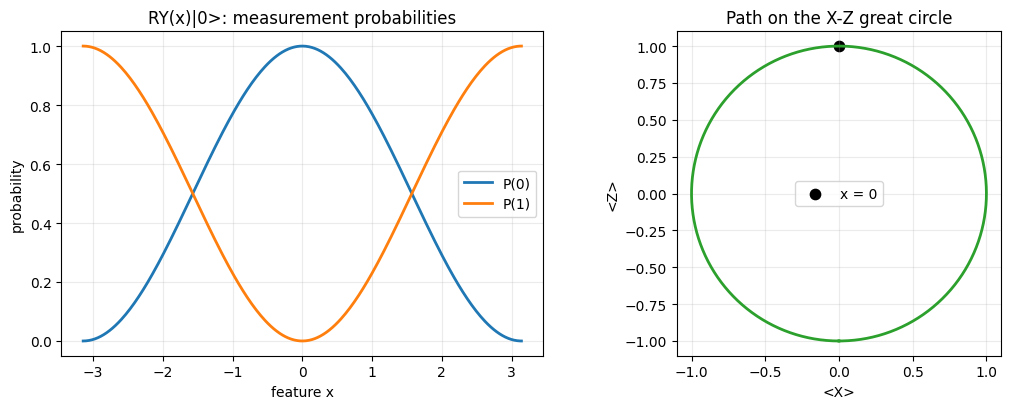

In [ ]:
# Pseudo-code:
#   1. sweep one angle feature
#   2. compute measurement probabilities
#   3. plot probabilities and Bloch coordinates

# this code explores the one-qubit angle encoding, where we apply a rotation around the Y-axis (RY) to the |0> state, parameterized by an angle x.
# The resulting state is a superposition of |0> and |1>, and we can compute the probabilities of measuring each outcome
# as well as the corresponding Bloch vector components. 
# The left plot shows how the measurement probabilities P(0) and P(1) vary with the angle x, 
# while the right plot illustrates the path traced on the X-Z plane of the Bloch sphere as x is varied, 
# showing how the state evolves from |0> to |1> and back along a great circle.

# One-qubit angle encoding: probabilities and Bloch-vector components.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt

x_values = np.linspace(-np.pi, np.pi, 300)
p0 = np.cos(x_values / 2.0) ** 2
p1 = np.sin(x_values / 2.0) ** 2
bloch_x = np.sin(x_values)
bloch_z = np.cos(x_values)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(x_values, p0, color="tab:blue", linewidth=2, label="P(0)")
axes[0].plot(x_values, p1, color="tab:orange", linewidth=2, label="P(1)")
axes[0].set_title("RY(x)|0>: measurement probabilities")
axes[0].set_xlabel("feature x")
axes[0].set_ylabel("probability")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(bloch_x, bloch_z, color="tab:green", linewidth=2)
axes[1].scatter([0], [1], color="black", s=55, label="x = 0")
axes[1].set_title("Path on the X-Z great circle")
axes[1].set_xlabel("<X>")
axes[1].set_ylabel("<Z>")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


In [1]:
# Pseudo-code:
#   1. define a PennyLane device
#   2. encode two features with rotations
#   3. entangle qubits and measure observables
#   4. print circuit outputs

# First PennyLane circuit: encode two features and measure observables.
# Setup: imports and initial values for this cell.
import numpy as np
import pennylane as qml

x = np.array([0.7, -1.1])
dev = qml.device("default.qubit", wires=2)
# Create the quantum simulator backend.

@qml.qnode(dev)
def feature_circuit(features):
    # Define the reusable computation for this cell.
    qml.RY(features[0], wires=0)
    # Apply a quantum operation or declare a measurement.
    qml.RY(features[1], wires=1)
    # Apply a quantum operation or declare a measurement.
    qml.CNOT(wires=[0, 1])
    # Returning a tuple of expectation values and probabilities.
    # PauliZ(0) and PauliZ(1) are the Z-basis measurements on qubits 0 and 1, respectively, 
    # which give us information about the state of each qubit after encoding and entanglement.
    return (
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.probs(wires=[0, 1]),
    )
    # Return the computed output for the caller.

z0, z1, probabilities = feature_circuit(x)
# Compute model outputs for the current data.

print(qml.draw(feature_circuit)(x))
print("input features:", np.round(x, 3))
print("<Z0>, <Z1>:", round(float(z0), 3), round(float(z1), 3))
print("basis probabilities |00>, |01>, |10>, |11>:", np.round(probabilities, 3))


0: ──RY(0.70)──╭●─┤  <Z> ╭Probs
1: ──RY(-1.10)─╰X─┤  <Z> ╰Probs
input features: [ 0.7 -1.1]
<Z0>, <Z1>: 0.765 0.347
basis probabilities |00>, |01>, |10>, |11>: [0.641 0.241 0.032 0.085]


## Quantum kernels

A quantum kernel compares two encoded states:

$$
K(x,z) = |\langle 0|U_\phi(x)^\dagger U_\phi(z)|0\rangle|^2.
$$

For the one-qubit map $U_\phi(x)=R_Y(x)$, the overlap can be computed exactly:

$$
\langle \phi(x)|\phi(z)\rangle
=
\cos\left(\frac{x-z}{2}\right),
\qquad
K(x,z)=\cos^2\left(\frac{x-z}{2}\right).
$$

A kernel matrix stores all pairwise similarities:

$$
K_{ij} = K(x_i,x_j).
$$

Kernel methods do not need to explicitly read out the whole feature vector. They only need inner products or overlaps.


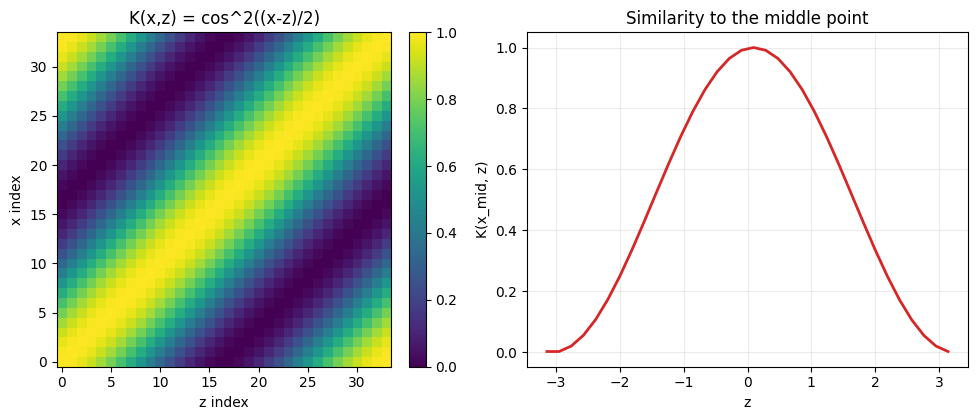

maximum analytic-vs-PennyLane difference: 4.440892098500626e-16


In [4]:
# Pseudo-code:
#   1. build an analytic one-qubit kernel
#   2. compute the same kernel from state overlaps
#   3. compare and visualize similarities

# One-qubit quantum kernel: analytic formula and PennyLane state overlaps.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

x_values = np.linspace(-np.pi, np.pi, 34)
analytic_kernel = np.cos((x_values[:, None] - x_values[None, :]) / 2.0) ** 2
# Compute pairwise similarities for the kernel method.

dev = qml.device("default.qubit", wires=1)
# Create the quantum simulator backend.

@qml.qnode(dev)
def encoded_state(x):
    # Define the reusable computation for this cell.
    qml.RY(x, wires=0)
    # Apply a quantum operation or declare a measurement.
    return qml.state()
    # Return the computed output for the caller.

states = np.array([encoded_state(x) for x in x_values])
# Store quantum-state amplitudes for overlap calculations.
pennylane_kernel = np.abs(states @ states.conj().T) ** 2
# Compute pairwise similarities for the kernel method.
max_difference = np.max(np.abs(analytic_kernel - pennylane_kernel))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))

image = axes[0].imshow(analytic_kernel, origin="lower", cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("K(x,z) = cos^2((x-z)/2)")
axes[0].set_xlabel("z index")
axes[0].set_ylabel("x index")
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].plot(x_values, analytic_kernel[len(x_values) // 2], color="tab:red", linewidth=2)
axes[1].set_title("Similarity to the middle point")
axes[1].set_xlabel("z")
axes[1].set_ylabel("K(x_mid, z)")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("maximum analytic-vs-PennyLane difference:", max_difference)


## A two-qubit feature map

More expressive feature maps use entangling gates and feature products. One simple two-qubit example is

$$
U_\phi(x)
=
\mathrm{CNOT}_{0,1}
R_Z(x_1x_2)_1
R_Y(x_2)_1
R_Y(x_1)_0.
$$

The product term \(x_1x_2\) and the entangling gate make the kernel depend on correlations between features. This is still a tiny circuit, but it already illustrates the QML pattern: data are not just fed into a model, they are used to define a quantum state.


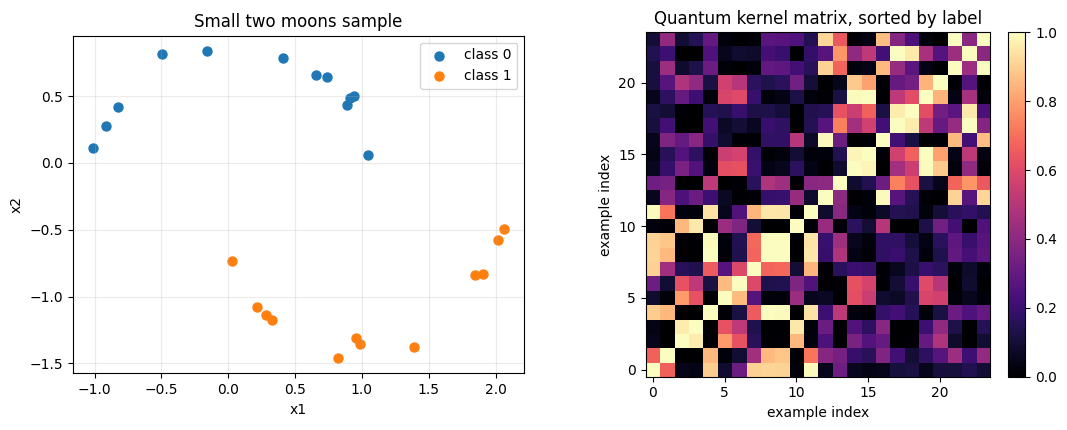

kernel shape: (24, 24)
kernel diagonal min/max: 1.0 1.0


In [5]:
# Pseudo-code:
#   1. generate a small nonlinear dataset
#   2. encode points with a two-qubit feature map
#   3. compute pairwise state overlaps
#   4. plot data and sorted kernel matrix

# Two-qubit quantum kernel matrix on a small nonlinear dataset.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

rng = np.random.default_rng(12)
n_per_class = 12
angles_a = rng.uniform(0.0, np.pi, n_per_class)
angles_b = rng.uniform(0.0, np.pi, n_per_class)
moon_a = np.column_stack([np.cos(angles_a), np.sin(angles_a)])
moon_b = np.column_stack([1.0 - np.cos(angles_b), -np.sin(angles_b) - 0.45])
X_raw = np.vstack([moon_a, moon_b]) + rng.normal(0.0, 0.08, size=(2 * n_per_class, 2))
y = np.r_[np.zeros(n_per_class), np.ones(n_per_class)]

X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = np.clip(X, -2.2, 2.2) * (np.pi / 2.2)

dev = qml.device("default.qubit", wires=2)
# Create the quantum simulator backend.

@qml.qnode(dev)
def feature_state(features):
    # Define the reusable computation for this cell.
    qml.RY(features[0], wires=0)
    # Apply a quantum operation or declare a measurement.
    qml.RY(features[1], wires=1)
    # Apply a quantum operation or declare a measurement.
    qml.RZ(0.6 * features[0] * features[1], wires=1)
    # Apply a quantum operation or declare a measurement.
    qml.CNOT(wires=[0, 1])
    # Apply a quantum operation or declare a measurement.
    return qml.state()
    # Return the computed output for the caller.

states = np.array([feature_state(x) for x in X])
# Store quantum-state amplitudes for overlap calculations.
kernel = np.abs(states @ states.conj().T) ** 2
# Compute pairwise similarities for the kernel method.

order = np.argsort(y)
sorted_kernel = kernel[order][:, order]
# Compute pairwise similarities for the kernel method.

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4))
axes[0].scatter(X_raw[y == 0, 0], X_raw[y == 0, 1], s=42, color="tab:blue", label="class 0")
axes[0].scatter(X_raw[y == 1, 0], X_raw[y == 1, 1], s=42, color="tab:orange", label="class 1")
axes[0].set_title("Small two moons sample")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.25)
axes[0].legend()

image = axes[1].imshow(sorted_kernel, origin="lower", cmap="magma", vmin=0, vmax=1)
axes[1].set_title("Quantum kernel matrix, sorted by label")
axes[1].set_xlabel("example index")
axes[1].set_ylabel("example index")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("kernel shape:", kernel.shape)
print("kernel diagonal min/max:", round(float(kernel.diagonal().min()), 6), round(float(kernel.diagonal().max()), 6))


## Applied example: kernel classification

A simple kernel classifier can be built without training a variational circuit. Use labels $y_i \in \{-1,+1\}$, compute the training kernel matrix $K$, and solve a regularized linear system:

$$
(K + \lambda I)\alpha = y.
$$

A new point \(x\) is classified by

$$
f(x) = \sum_{i=1}^{n} \alpha_i K(x_i, x),
\qquad
\hat y = \mathrm{sign}(f(x)).
$$

This is kernel ridge classification. The quantum part is the kernel evaluation $K(x,z)=|\langle\phi(x)|\phi(z)\rangle|^2$. The rest is ordinary linear algebra.


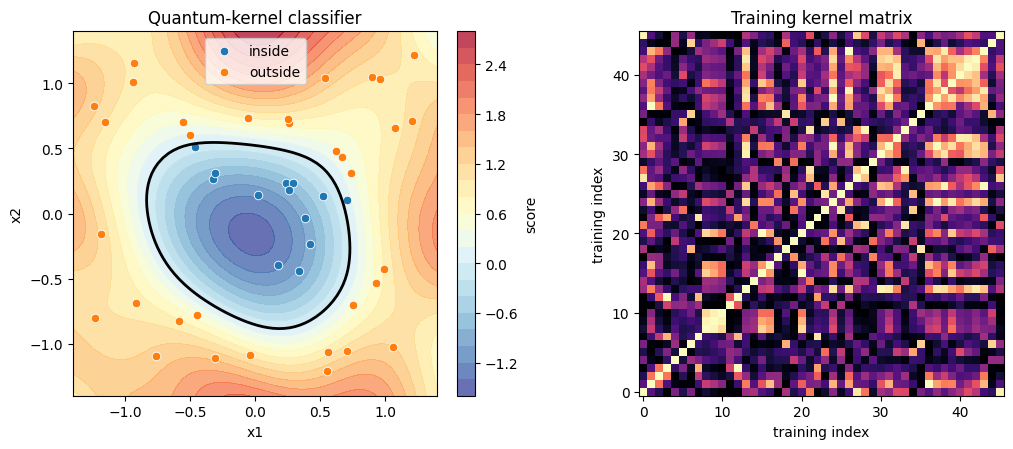

training accuracy=0.978
alpha range: -13.768 to 10.195


In [ ]:
# Pseudo-code:
#   1. generate a circle classification dataset
#   2. compute quantum-kernel training similarities
#   3. solve kernel ridge coefficients. Ridge coefficients are the weights assigned to each training example in the kernel method, 
#      which are determined by solving a linear system that incorporates the kernel matrix and a regularization term. 
#      These coefficients allow us to make predictions for new data points based on their similarity to the training examples.
#   4. plot the classifier decision surface

# Quantum-kernel ridge classification on a small circle dataset.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

rng = np.random.default_rng(9)
n_train = 46
X_raw = rng.uniform(-1.25, 1.25, size=(n_train, 2))
radius = np.sqrt(np.sum(X_raw**2, axis=1))
y = np.where(radius > 0.72, 1.0, -1.0)

feature_mean = X_raw.mean(axis=0)
feature_scale = X_raw.std(axis=0)
X = (X_raw - feature_mean) / feature_scale
X = np.clip(X, -2.4, 2.4) * (np.pi / 2.4)

dev = qml.device("default.qubit", wires=2)
# Create the quantum simulator backend.

@qml.qnode(dev)
def feature_state(features):
    # Define the reusable computation for this cell.
    qml.RY(features[0], wires=0)
    # Apply a quantum operation or declare a measurement.
    qml.RY(features[1], wires=1)
    # Apply a quantum operation or declare a measurement.
    qml.CNOT(wires=[0, 1])
    # Apply a quantum operation or declare a measurement.
    qml.RZ(0.8 * features[0] * features[1], wires=1)
    # Apply a quantum operation or declare a measurement.
    qml.CNOT(wires=[1, 0])
    # Apply a quantum operation or declare a measurement.
    return qml.state()
    # Return the computed output for the caller.

train_states = np.array([feature_state(x) for x in X])
# Store quantum-state amplitudes for overlap calculations.
K_train = np.abs(train_states @ train_states.conj().T) ** 2
# Compute pairwise similarities for the kernel method.
regularization = 0.08
alpha = np.linalg.solve(K_train + regularization * np.eye(n_train), y)
# Solve the linear system for model coefficients.

grid_x = np.linspace(-1.4, 1.4, 70)
grid_y = np.linspace(-1.4, 1.4, 70)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_raw = np.column_stack([xx.ravel(), yy.ravel()])
grid = (grid_raw - feature_mean) / feature_scale
grid = np.clip(grid, -2.4, 2.4) * (np.pi / 2.4)
grid_states = np.array([feature_state(x) for x in grid])
# Store quantum-state amplitudes for overlap calculations.
K_grid = np.abs(train_states @ grid_states.conj().T) ** 2
# Compute pairwise similarities for the kernel method.
scores = alpha @ K_grid
# Compute model outputs for the current data.
score_map = scores.reshape(xx.shape)

train_scores = alpha @ K_train
# Compute model outputs for the current data.
train_pred = np.where(train_scores >= 0.0, 1.0, -1.0)
train_accuracy = np.mean(train_pred == y)
# Measure classification performance.

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

background = axes[0].contourf(xx, yy, score_map, levels=24, cmap="RdYlBu_r", alpha=0.75)
axes[0].contour(xx, yy, score_map, levels=[0.0], colors="black", linewidths=2)
axes[0].scatter(X_raw[y == -1, 0], X_raw[y == -1, 1], s=38, color="tab:blue", edgecolor="white", linewidth=0.6, label="inside")
axes[0].scatter(X_raw[y == 1, 0], X_raw[y == 1, 1], s=38, color="tab:orange", edgecolor="white", linewidth=0.6, label="outside")
axes[0].set_title("Quantum-kernel classifier")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend()
fig.colorbar(background, ax=axes[0], fraction=0.046, pad=0.04, label="score")

axes[1].imshow(K_train, origin="lower", cmap="magma", vmin=0, vmax=1)
axes[1].set_title("Training kernel matrix")
axes[1].set_xlabel("training index")
axes[1].set_ylabel("training index")

plt.tight_layout()
plt.show()

print(f"training accuracy={train_accuracy:.3f}")
print("alpha range:", round(float(alpha.min()), 3), "to", round(float(alpha.max()), 3))


## Key points

A quantum feature map is a circuit $U_\phi(x)$ whose gates depend on data.

A quantum kernel measures similarity between encoded states:

$$
K(x,z)=|\langle \phi(x)|\phi(z)\rangle|^2.
$$

Kernel classification uses quantum overlaps but classical linear algebra. This makes it a clean first QML model: the quantum device supplies similarities, while the classical computer solves the regularized system and evaluates predictions.
